In [ ]:
!pip install xgboost lightgbm shap -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

In [2]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv


In [4]:
df = pd.read_csv("placement_predict_50k Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())
df.info()
df.describe(include="all").T

Number of rows: 50000
Number of columns: 32

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Special

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StudentID,50000.0,NaN,NaN,NaN,25000.5,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Gender,50000,2,Male,30133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,10,Hyderabad,8114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CollegeTier,50000,3,Tier2,23315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stream,50000,6,CS,13937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Specialisation,50000,4,Embedded,13614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hostel,50000,2,Yes,27785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HistoryOfBacklogs,50000,2,No,40893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SGPA_Sem1,50000.0,NaN,NaN,NaN,7.210583,1.517846,4.0,6.09,7.19,8.34,10.0
SGPA_Sem2,50000.0,NaN,NaN,NaN,7.222243,1.532008,4.0,6.09,7.21,8.36,10.0


In [6]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
dtype: int64


In [7]:
print(df["PlacementStatus"].value_counts())

PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


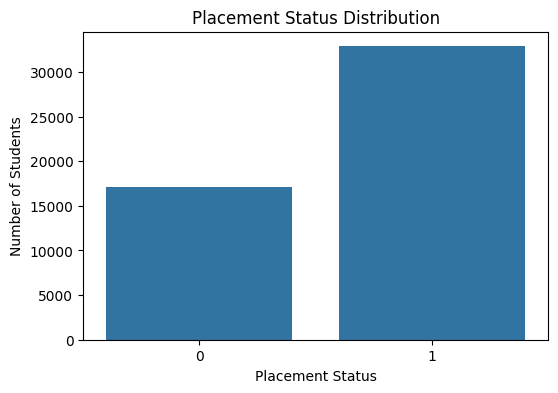

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x="PlacementStatus", data=df)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (50000, 32)


In [10]:
drop_columns = [
    "StudentID",
    "Salary Package",
    "IsAnomaly"
]

df = df.drop(columns=drop_columns)

print("Shape after removing unnecessary columns:", df.shape)

Shape after removing unnecessary columns: (50000, 29)


In [11]:
X = df.drop("PlacementStatus", axis=1)
y = df["PlacementStatus"]

In [12]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 28)
Target shape: (50000,)


In [13]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']


In [14]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

Shape after encoding: (50000, 44)


In [15]:
X = X.fillna(X.median(numeric_only=True))
print("Remaining missing values:")
print(X.isnull().sum().sum())

Remaining missing values:
0


In [16]:
print(y.unique())
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(np.unique(y))

[0 1]
[0 1]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 44)
Testing data: (10000, 44)


In [18]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [19]:
xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [20]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [21]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

XGBoost Results
-------------------------
Accuracy : 0.922
Precision: 0.9272539471742659
Recall   : 0.9563232384720742
F1 Score : 0.941564279292778
ROC-AUC  : 0.980185122829311


In [22]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3429
           1       0.93      0.96      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000



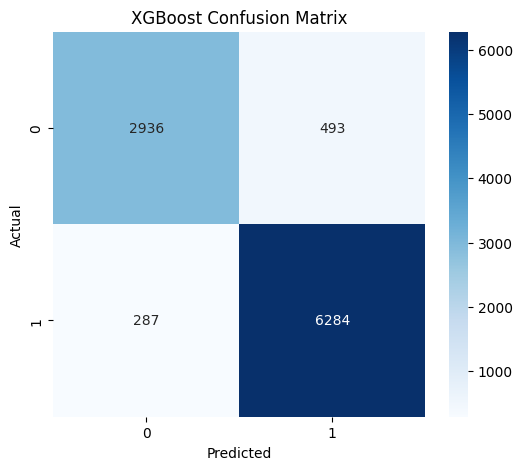

In [23]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
importance_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance_xgb.head(15))

SGPA_Sem8                0.303487
SGPA_Sem7                0.116735
Projects                 0.099113
SGPA_Sem6                0.066220
CGPA_Tier_Low            0.042000
MockInterviewScore       0.041259
HistoryOfBacklogs_Yes    0.039052
CGPA_Tier_Mid            0.035536
Internships              0.034096
SoftSkillsRating         0.024691
CodingTestScore          0.021288
SGPA_Sem5                0.016766
CGPA                     0.016312
Certifications           0.008140
Publications             0.007616
dtype: float32


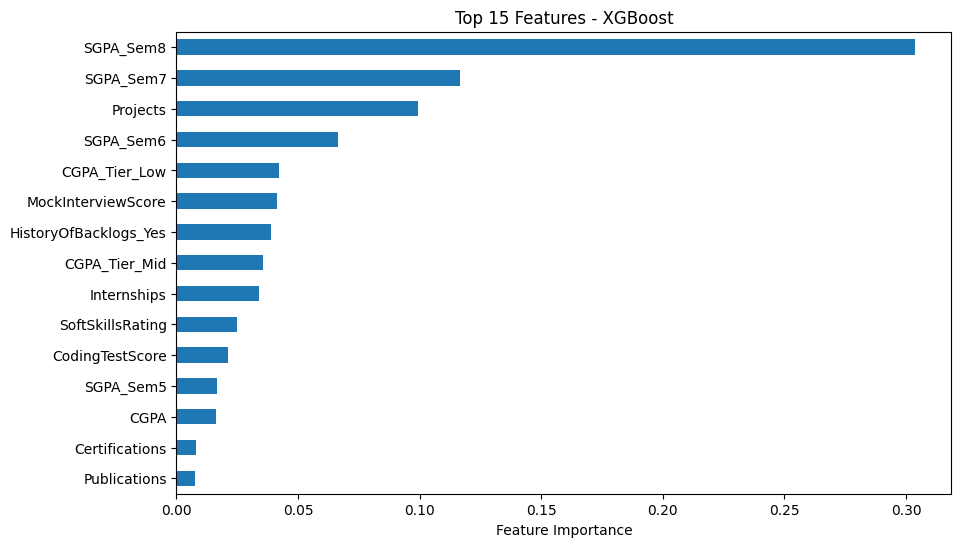

In [25]:
plt.figure(figsize=(10,6))

importance_xgb.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Features - XGBoost")
plt.xlabel("Feature Importance")

plt.show()

In [26]:
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)

print("LightGBM training completed!")

LightGBM training completed!


In [27]:
y_pred_lgb = lgb_model.predict(X_test)

y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

In [28]:
lgb_accuracy = accuracy_score(y_test, y_pred_lgb)
lgb_precision = precision_score(y_test, y_pred_lgb)
lgb_recall = recall_score(y_test, y_pred_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb)
lgb_auc = roc_auc_score(y_test, y_prob_lgb)

print("LightGBM Results")
print("-------------------------")
print("Accuracy :", lgb_accuracy)
print("Precision:", lgb_precision)
print("Recall   :", lgb_recall)
print("F1 Score :", lgb_f1)
print("ROC-AUC  :", lgb_auc)

LightGBM Results
-------------------------
Accuracy : 0.9217
Precision: 0.9273479031305375
Recall   : 0.9557145031197687
F1 Score : 0.9413175447800345
ROC-AUC  : 0.9802785013056344


In [29]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88      3429
           1       0.93      0.96      0.94      6571

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000



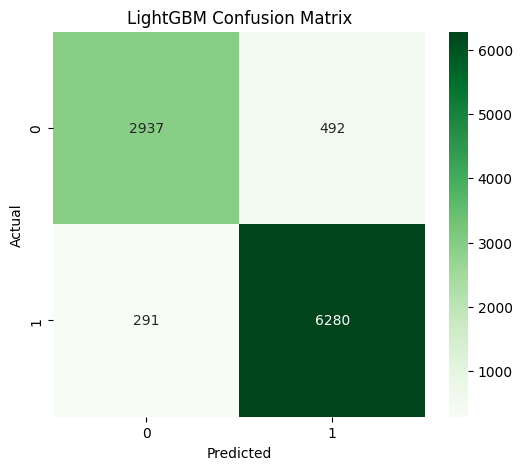

In [30]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lgb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [xgb_accuracy, lgb_accuracy],
    "Precision": [xgb_precision, lgb_precision],
    "Recall": [xgb_recall, lgb_recall],
    "F1 Score": [xgb_f1, lgb_f1],
    "ROC-AUC": [xgb_auc, lgb_auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9220,0.927254,0.956323,0.941564,0.980185
1,LightGBM,0.9217,0.927348,0.955715,0.941318,0.980279


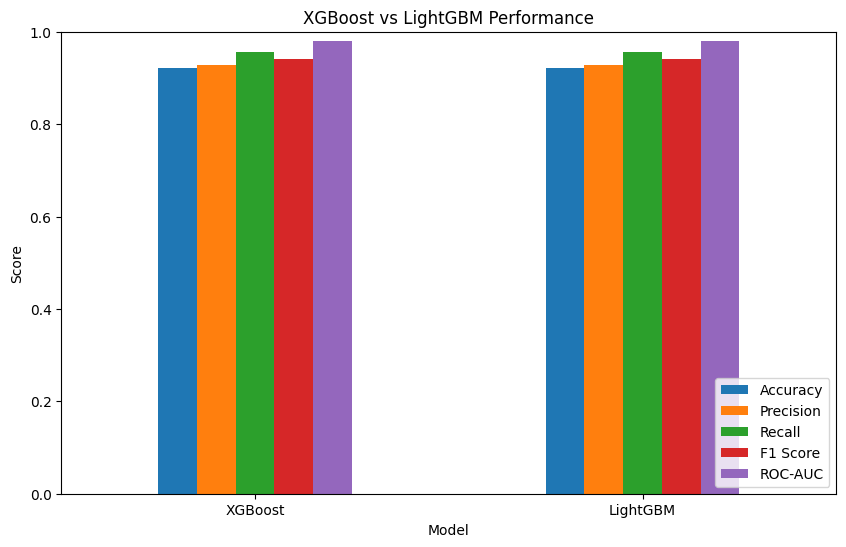

In [32]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("XGBoost vs LightGBM Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()